In [ ]:
import argparse
import numpy as np
import pandas as pd
import os
import torch
import torch.nn as nn
import datetime
import time
# import matplotlib.pyplot as plt
# %matplotlib widget
from torchinfo import summary
import yaml
import json
import sys
import copy
from torch import optim
# 统计flop、gpu、时长
import torch.cuda.profiler as profiler
from thop import profile
from sklearn.manifold import TSNE
from adjustText import adjust_text  # 在代码开头添加这
sys.path.append("../..")
from lib.utils import (
    MaskedMAELoss,
    print_log,
    seed_everything,
    set_cpu_num,
    CustomJSONEncoder,
)
from lib.metrics import RMSE_MAE_MAPE
from lib.data_prepare import get_dataloaders_from_index_data
from model.SRCA import SRCA
from model.SRCA_abla1 import SRCA_abla1
from model.SRCA_abla2 import SRCA_abla2
from model.SRCA_abla3 import SRCA_abla3
from model.SRCA_abla4 import SRCA_abla4
from model.SRCA_abla5 import SRCA_abla5
from model.SRCA_abla6 import SRCA_abla6
from model.SRCA_abla7 import SRCA_abla7
from model.SRCA_abla8 import SRCA_abla8
from model.SRCA_abla9 import SRCA_abla9
from model.SRCA_abla10 import SRCA_abla10
from model.SRCA_abla11 import SRCA_abla11
from model.SRCA_abla12 import SRCA_abla12

In [ ]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    y = []
    out = []

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        out_batch, loss_route = model(x_batch)
        out_batch = SCALER.inverse_transform(out_batch)

        out_batch = out_batch.cpu().numpy()
        y_batch = y_batch.cpu().numpy()
        out.append(out_batch)
        y.append(y_batch)

    out = np.vstack(out).squeeze()  # (samples, out_steps, num_nodes)
    y = np.vstack(y).squeeze()

    return y, out

In [3]:
available_models = {
    "SRCA": SRCA,
    "SRCA_abla1": SRCA_abla1,
    "SRCA_abla2": SRCA_abla2,
    "SRCA_abla3": SRCA_abla3,
    "SRCA_abla4": SRCA_abla4,
    "SRCA_abla5": SRCA_abla5,
    "SRCA_abla6": SRCA_abla6,
    "SRCA_abla7": SRCA_abla7,
    "SRCA_abla8": SRCA_abla8,
    "SRCA_abla9": SRCA_abla9,
    "SRCA_abla10": SRCA_abla10,
    "SRCA_abla11": SRCA_abla11,
    "SRCA_abla12": SRCA_abla12,
}

In [5]:
(
    trainset_loader,
    valset_loader,
    testset_loader,
    SCALER,
) = get_dataloaders_from_index_data(
    f"../data/{dataset}",
    tod=cfg.get("time_of_day"),
    dow=cfg.get("day_of_week"),
    batch_size=cfg.get("batch_size", 64),
)

Trainset:	x-(16921, 12, 883, 3)	y-(16921, 12, 883, 1)
Valset:  	x-(5640, 12, 883, 3)  	y-(5640, 12, 883, 1)
Testset:	x-(5640, 12, 883, 3)	y-(5640, 12, 883, 1)


In [6]:
model.eval()

start = time.time()
y_true, y_pred = predict(model, valset_loader)
end = time.time()

rmse_all, mae_all, mape_all = RMSE_MAE_MAPE(y_true, y_pred)
out_str = "All Steps RMSE = %.5f, MAE = %.5f, MAPE = %.5f\n" % (
    rmse_all,
    mae_all,
    mape_all,
)
out_steps = y_pred.shape[1]
for i in range(out_steps):
    rmse, mae, mape = RMSE_MAE_MAPE(y_true[:, i, :], y_pred[:, i, :])
    out_str += "Step %d RMSE = %.5f, MAE = %.5f, MAPE = %.5f\n" % (
        i + 1,
        rmse,
        mae,
        mape,
    )
print_log(out_str, end="")
print_log("Inference time: %.2f s" % (end - start))

All Steps RMSE = 32.10706, MAE = 18.42248, MAPE = 7.98519
Step 1 RMSE = 26.45348, MAE = 15.81153, MAPE = 6.84093
Step 2 RMSE = 28.24449, MAE = 16.57579, MAPE = 7.16097
Step 3 RMSE = 29.49756, MAE = 17.15829, MAPE = 7.40322
Step 4 RMSE = 30.49915, MAE = 17.63245, MAPE = 7.60663
Step 5 RMSE = 31.34835, MAE = 18.04486, MAPE = 7.78676
Step 6 RMSE = 32.10646, MAE = 18.42235, MAPE = 7.95733
Step 7 RMSE = 32.80059, MAE = 18.77052, MAPE = 8.11500
Step 8 RMSE = 33.44563, MAE = 19.10563, MAPE = 8.27275
Step 9 RMSE = 34.03108, MAE = 19.41367, MAPE = 8.42162
Step 10 RMSE = 34.59035, MAE = 19.72072, MAPE = 8.57649
Step 11 RMSE = 35.14812, MAE = 20.03847, MAPE = 8.74265
Step 12 RMSE = 35.70668, MAE = 20.38393, MAPE = 8.94157
Inference time: 38.99 s


route_x_updated shape: (R=4, K=240, D=80)
topk_idx shape: (R=4, topk=240)
x_batch shape: (T=1, C=883, D=80) → 总点数=N_total=883
features_center shape: (R=4, D=80)
Flattened route features shape: torch.Size([960, 80])
Route labels shape: (960,)
Unselected features shape: torch.Size([164, 80])
Unselected labels shape: (164,)
All features shape: torch.Size([1128, 80])
All labels shape: (1124,)


C:\Users\SHU47\AppData\Local\Temp\ipykernel_49032\2821494627.py:48: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(features_route),        # 路由选中点 (R*K, D)
C:\Users\SHU47\AppData\Local\Temp\ipykernel_49032\2821494627.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(features_unselected),   # 未被选中点 (N_unselected, D)
C:\Users\SHU47\AppData\Local\Temp\ipykernel_49032\2821494627.py:101: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


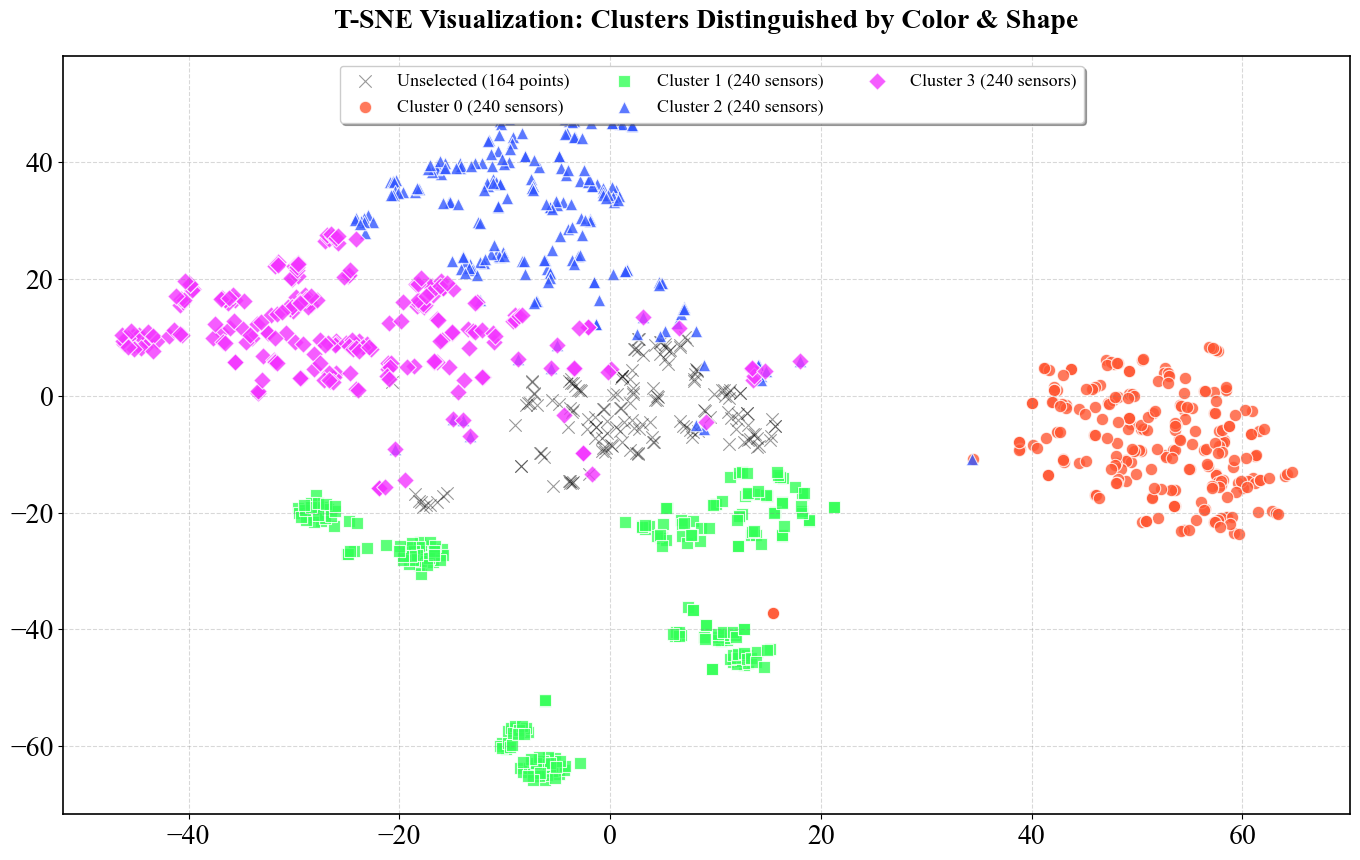


=== 关键统计信息 ===
原始x_batch总点数: 883
被选中的唯一点数: 719
未被选中的点数: 164
各路由选中点数: 每个路由240个，共960个（可能有重复选中）

=== 形状分配说明 ===
路由簇形状列表: ['o', 's', '^', 'D']（共4个簇）
未选中点形状: x（灰色叉号）
中心点形状: *（星号，突出核心）
注：若簇重叠严重，可调整形状大小（s参数）或更换形状组合


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.manifold import TSNE

plt.rcParams['font.family'] = 'Times New Roman'  # 全局字体
plt.rcParams['font.size'] = 20  # 全局基础字体大小（后续可针对性调整局部元素）
plt.rcParams['axes.linewidth'] = 1.2  # 坐标轴线条宽度，增强图表清晰度

# 假设你已经有了 model 及相关张量（route_x、topk_idx、route_node_t、x）
batch_idx = 0
lay_num = 1
route_x_batch = model.attn_layers_s[lay_num].route_x_updated[batch_idx].cpu()  # (R,K,D)
topk_idx_batch = model.attn_layers_s[lay_num].topk_idx[batch_idx].cpu()        # (R,topk)
x_batch = model.attn_layers_s[lay_num].x[batch_idx].cpu()                      # (T,C,D)
features_center = model.attn_layers_s[lay_num].route_node_t[batch_idx].cpu()   # (R,D)

# 打印维度信息
R = route_x_batch.shape[0]  # 路由数
K = route_x_batch.shape[1]  # 每个路由选中的topk数
D = route_x_batch.shape[2]  # 特征维度
T, C = x_batch.shape[0], x_batch.shape[1]
N_total = T * C  # 总点数
print(f"route_x_updated shape: (R={R}, K={K}, D={D})")
print(f"topk_idx shape: (R={R}, topk={topk_idx_batch.shape[1]})")
print(f"x_batch shape: (T={T}, C={C}, D={D}) → 总点数=N_total={N_total}")
print(f"features_center shape: (R={R}, D={D})")

# -------------------------- 步骤1：处理各路由选中的点 --------------------------
features_route = route_x_batch.reshape(-1, D)  # (R*K, D)
labels_route = np.repeat(np.arange(R), K)      # 标签0~R-1
print(f"Flattened route features shape: {features_route.shape}")
print(f"Route labels shape: {labels_route.shape}")

# -------------------------- 步骤2：提取未被选中的点 --------------------------
x_flattened = x_batch.reshape(N_total, D)  # (T*C, D)
selected_indices = topk_idx_batch.cpu().numpy().flatten()
selected_indices = np.unique(selected_indices)
all_indices = np.arange(N_total)
unselected_indices = np.setdiff1d(all_indices, selected_indices)
features_unselected = x_flattened[unselected_indices]  # (N_unselected, D)
labels_unselected = np.full(len(unselected_indices), R)  # 标签设为R
print(f"Unselected features shape: {features_unselected.shape}")
print(f"Unselected labels shape: {labels_unselected.shape}")

# -------------------------- 步骤3：合并特征并T-SNE降维 --------------------------
features_all = torch.cat([
    torch.tensor(features_route),        # 路由选中点 (R*K, D)
    torch.tensor(features_unselected),   # 未被选中点 (N_unselected, D)
    features_center                      # 路由中心点 (R, D)
], dim=0)

labels_all = np.concatenate([labels_route, labels_unselected], axis=0)
print(f"All features shape: {features_all.shape}")
print(f"All labels shape: {labels_all.shape}")

# T-SNE降维
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=2000,
    random_state=42,
    init='pca'
)
all_features_2d = tsne.fit_transform(features_all.detach().cpu().float().numpy())

# 分离三类数据
N_route = len(labels_route)
N_unselected = len(labels_unselected)
N_centers = R
features_route_2d = all_features_2d[:N_route]
features_unselected_2d = all_features_2d[N_route:N_route+N_unselected]
centers_2d = all_features_2d[-N_centers:]

# -------------------------- 核心修改：定义簇专属形状（marker）--------------------------
# 1. 定义易区分的形状列表（可根据需要扩展，优先选视觉差异大的形状）
# 常用形状：'o'(圆)、's'(正方形)、'^'(上三角形)、'D'(菱形)、'v'(下三角形)、'<'(左三角形)、'>'(右三角形)、'p'(五边形)、'h'(六边形)
marker_list = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h', '8', 'P', 'X']  # 12种基础形状
# 若路由数R超过形状列表长度，循环使用形状（或扩展列表）
if R > len(marker_list):
    # 扩展形状列表（添加填充/空心变体）
    marker_list += ['o', 's', '^', 'D']  # 重复基础形状，通过颜色区分
    print(f"路由数R={R}超过预设形状数量，已扩展形状列表（循环使用）")

# 2. 为未选中点分配专属形状（与路由簇形状区分开）
unselected_marker = 'x'  # 叉号，突出未选中点的特殊性

# 3. 颜色方案（保留原有，与形状搭配）
custom_colors_route = ['#FF5733', '#33FF57', '#3357FF', '#F333FF', '#FFC300', '#58D68D',
                       '#8E44AD', '#E74C3C', '#17A2B8', '#FF7F50', '#98D8C8', '#F7DC6F']
if R > len(custom_colors_route):
    custom_colors_route = plt.cm.Set3(np.linspace(0, 1, R))  # 自动生成颜色
color_unselected = 'BLACK'  # 未选中点：灰色

# -------------------------- 步骤4：可视化（添加形状区分）--------------------------
plt.figure(figsize=(14, 9))
plt.rcParams['font.size'] = 20

# 1. 绘制未被选中的点（灰色+叉号）
plt.scatter(
    features_unselected_2d[:, 0], features_unselected_2d[:, 1],
    color=color_unselected, marker=unselected_marker,  # 专属形状
    alpha=0.4, label=f'Unselected ({len(unselected_indices)} points)',
    s=80, edgecolors='white', linewidth=0.8
)

# 2. 绘制各路由选中的点（专属颜色+专属形状）
for r in range(R):
    route_indices = labels_route == r
    plt.scatter(
        features_route_2d[route_indices, 0], features_route_2d[route_indices, 1],
        color=custom_colors_route[r], marker=marker_list[r % len(marker_list)],  # 分配形状（循环使用）
        alpha=0.8, label=f'Cluster {r} ({K} sensors)',
        s=80, edgecolors='white', linewidth=0.8  # 适当增大尺寸，突出形状
    )

# # 3. 绘制路由中心点（保留原有星号，突出核心）
# center_sizes = [min(120 + 20 * r, 350) for r in range(R)]
# for r in range(R):
#     plt.scatter(
#         centers_2d[r, 0], centers_2d[r, 1],
#         color=custom_colors_route[r], marker='*',  # 中心点专属形状：星号
#         s=center_sizes[r], edgecolors='black', linewidth=2.5, zorder=10
#     )
#     plt.annotate(f'Center {r}', (centers_2d[r, 0], centers_2d[r, 1]),
#                  xytext=(8, 8), textcoords='offset points', fontweight='bold', fontsize=11)

# 可视化美化
plt.title('T-SNE Visualization: Clusters Distinguished by Color & Shape',
          fontsize=20, fontweight='bold', pad=20)
# plt.xlabel('T-SNE Component 1', fontsize=20, labelpad=10)
# plt.ylabel('T-SNE Component 2', fontsize=20, labelpad=10)
plt.grid(True, alpha=0.3, linestyle='--', color='gray')
# 图例：自动显示颜色+形状的组合，无需额外修改
plt.legend(bbox_to_anchor=(0.8, 0.9), loc=4, frameon=True,
           shadow=True, ncol=3, fontsize=13)
plt.tight_layout()

# 保存图片（可选）
# plt.savefig(f'tsne_visualization_color_shape_batch_{batch_idx}.png', dpi=300, bbox_inches='tight')

plt.savefig('../fig/节点路由可视乎.jpg')
plt.show()

# -------------------------- 步骤5：输出关键统计信息（补充形状说明）--------------------------
print(f"\n=== 关键统计信息 ===")
print(f"原始x_batch总点数: {N_total}")
print(f"被选中的唯一点数: {len(selected_indices)}")
print(f"未被选中的点数: {len(unselected_indices)}")
print(f"各路由选中点数: 每个路由{K}个，共{R*K}个（可能有重复选中）")
print(f"\n=== 形状分配说明 ===")
print(f"路由簇形状列表: {marker_list[:R]}（共{R}个簇）")
print(f"未选中点形状: {unselected_marker}（灰色叉号）")
print(f"中心点形状: *（星号，突出核心）")
print(f"注：若簇重叠严重，可调整形状大小（s参数）或更换形状组合")

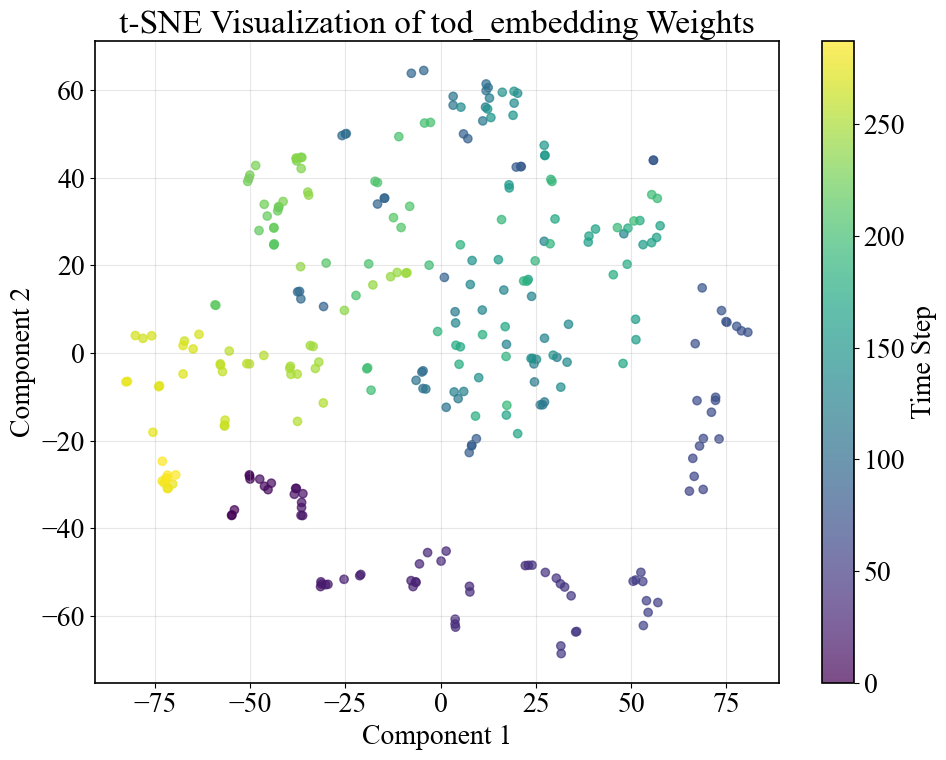

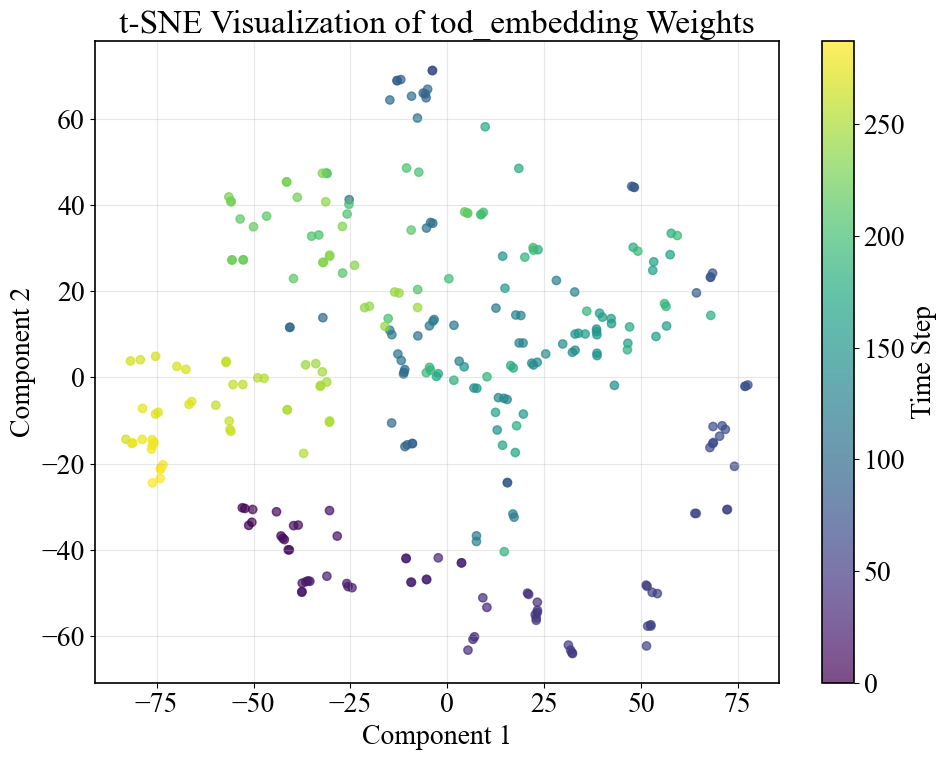

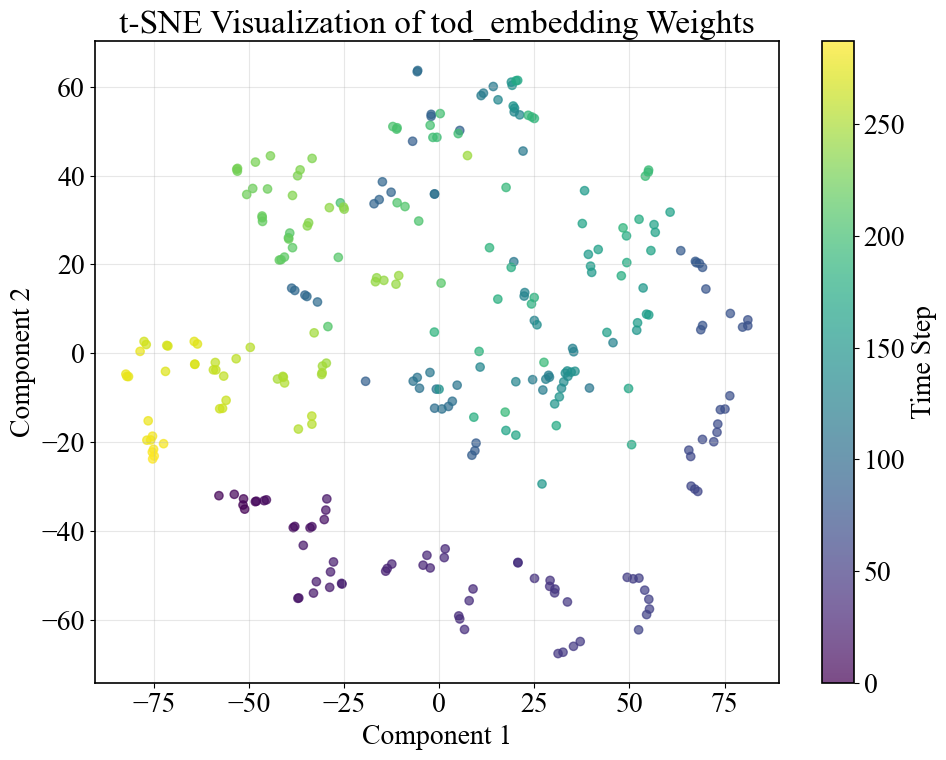

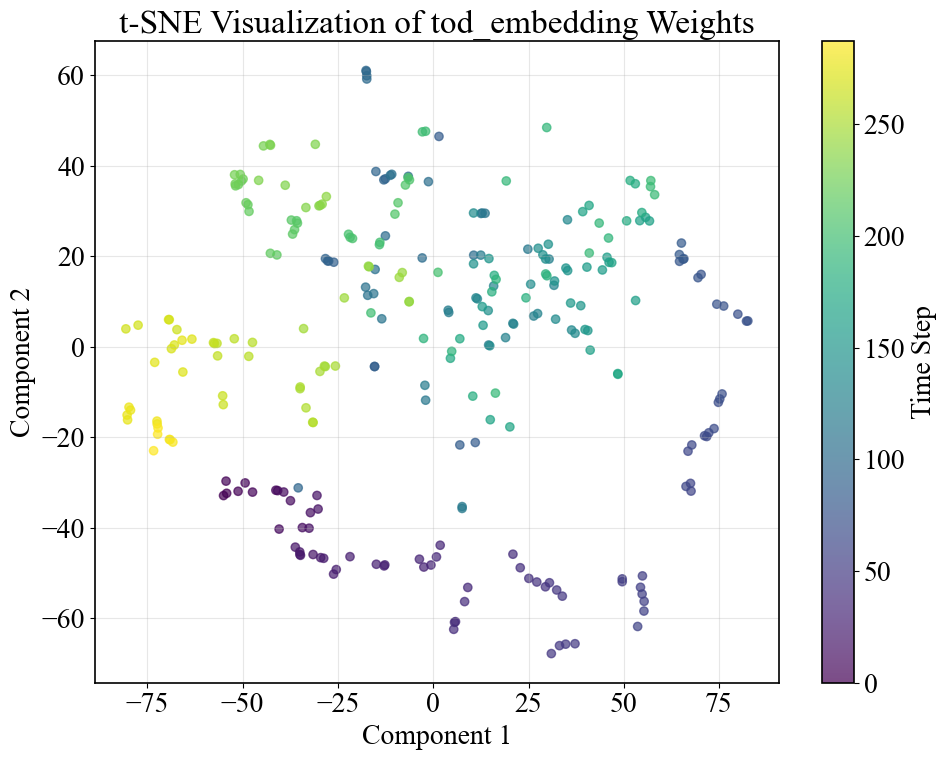

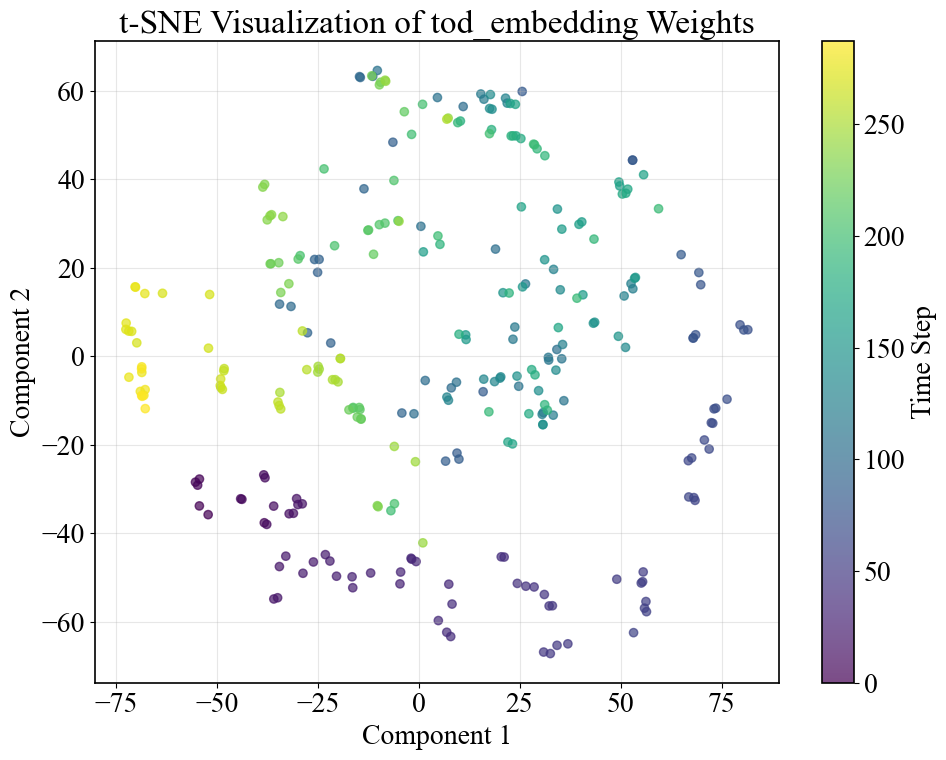

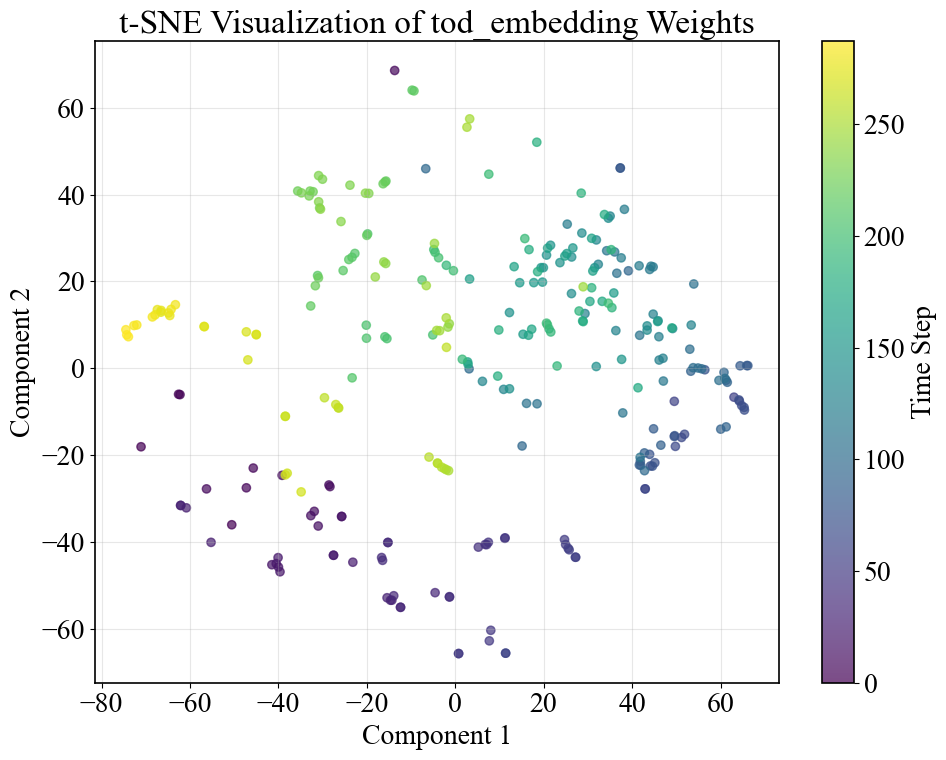

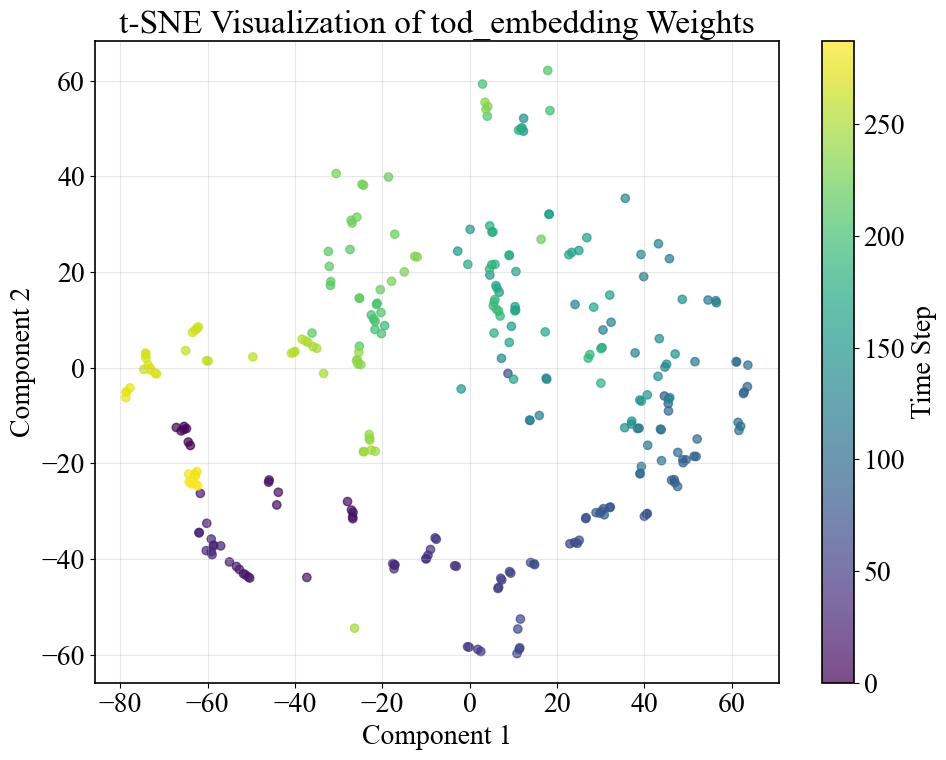

In [8]:
# 获取嵌入权重 (steps_per_day, tod_embedding_dim)
embedding_weights = model.week_embedding_all.detach().cpu().numpy()

# 使用 t-SNE 或 PCA 进行降维 
reducer = TSNE(n_components=2, random_state=42, perplexity=10)
title = 't-SNE Visualization of tod_embedding Weights' 
    
# from sklearn.decomposition import PCA
# reducer = PCA(n_components=2)
# title = 'PCA Visualization of tod_embedding Weights'
# 执行降维
embedded = reducer.fit_transform(embedding_weights)

# 绘制结果
for i in range(7):
    E = embedded[288*i:288*(i+1)]
    plt.figure(figsize=(10, 8))
    plt.scatter(E[:, 0], E[:, 1], c=np.arange(len(E)), cmap='viridis', alpha=0.7)

    # # 添加时间标注（每隔一定间隔标注一次）
    # step_interval = max(1, model.steps_per_day // 20)  # 最多标注20个点
    # for i in range(0, model.steps_per_day, step_interval):
    #     plt.annotate(str(i), (embedded[i, 0], embedded[i, 1]),
    #                 fontsize=8, alpha=0.7)

    plt.colorbar(label='Time Step')
    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

C:\Users\SHU47\AppData\Local\Temp\ipykernel_49032\1456834446.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 0.98])  # 布局不覆盖颜色条区域


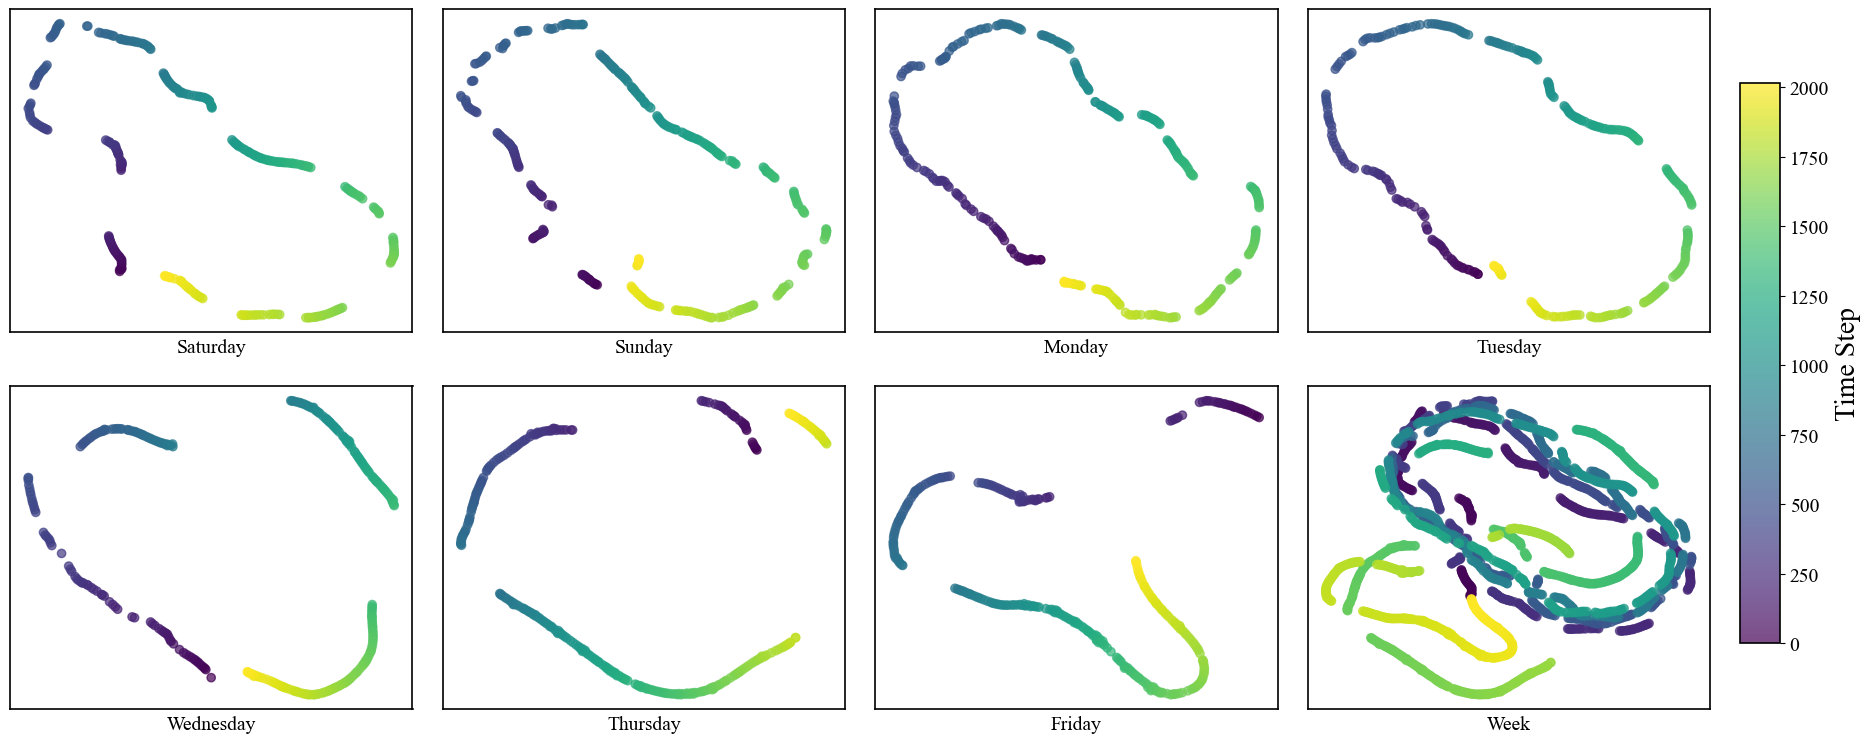

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 获取嵌入权重 (steps_per_day, tod_embedding_dim)
embedding_weights = model.week_embedding.detach().cpu().numpy()

# 使用 t-SNE 降维（保持你的参数）
reducer = TSNE(n_components=2, random_state=42, perplexity=15)
embedded = reducer.fit_transform(embedding_weights)

WEEK = ['Saturday','Sunday','Monday','Tuesday', 'Wednesday','Thursday','Friday',]
steps_per_day = 288  # 每日步数（和你的切片逻辑一致）

# ===================== 核心：创建7个子图 =====================
# 布局可选：1行7列（紧凑）或 2行4列（更美观），这里推荐2行4列（最后一列空）
fig, axes = plt.subplots(2, 4, figsize=(20, 8))  # 总画布尺寸：宽20，高8
axes = axes.flatten()  # 将2x4的轴数组展平为一维，方便循环

# 循环绘制每一天的子图
for i in range(7):
    ax = axes[i]  # 取第i个子图
    # 切片：取当天的嵌入数据
    start_idx = steps_per_day * i
    end_idx = steps_per_day * (i + 1)
    E = embedded[start_idx:end_idx]
    
    # 绘制散点图（子图版）
    scatter = ax.scatter(E[:, 0], E[:, 1], c=np.arange(len(E)), cmap='viridis', alpha=0.7)
    
    # 子图配置
    ax.set_xlabel(WEEK[i], fontsize=14)  # 子图x轴标注为星期几
    ax.grid(True, alpha=0.3)
    ax.set_xticks([])  # 可选：隐藏x轴刻度（避免拥挤）
    ax.set_yticks([])  # 可选：隐藏y轴刻度

ax = axes[7]
E = embedded

# 绘制散点图（子图版）
scatter = ax.scatter(E[:, 0], E[:, 1], c=np.arange(len(E)), cmap='viridis', alpha=0.7)

# 子图配置
ax.set_xlabel('Week', fontsize=14)  # 子图x轴标注为星期几
ax.grid(True, alpha=0.3)
ax.set_xticks([])  # 可选：隐藏x轴刻度（避免拥挤）
ax.set_yticks([])  # 可选：隐藏y轴刻度

# 隐藏第8个子图（2行4列的最后一列）
# axes[7].axis('off')
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
fig.subplots_adjust(right=0.85)  # 给颜色条留右侧15%的空间
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7],)  # [左, 下, 宽, 高]

# ===================== 统一配置 =====================
# 添加全局标题
# fig.suptitle('t-SNE Visualization of Week Embedding Weights', fontsize=16, y=0.95)

# 添加全局颜色条（所有子图共用）
cbar = fig.colorbar(scatter, cax=cbar_ax, label='Time Step' )
cbar.ax.tick_params(labelsize=14)

# 调整子图间距（避免重叠）
# plt.tight_layout(rect=[0, 0, 1, 0.98])  # rect参数给全局标题留空间

# fig.suptitle('t-SNE Visualization of Week Embedding Weights', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 0.88, 0.98])  # 布局不覆盖颜色条区域
# 保存整合后的图
plt.savefig("../fig/week_embedding_tsne_subplots.jpg", dpi=300, bbox_inches='tight')
plt.show()

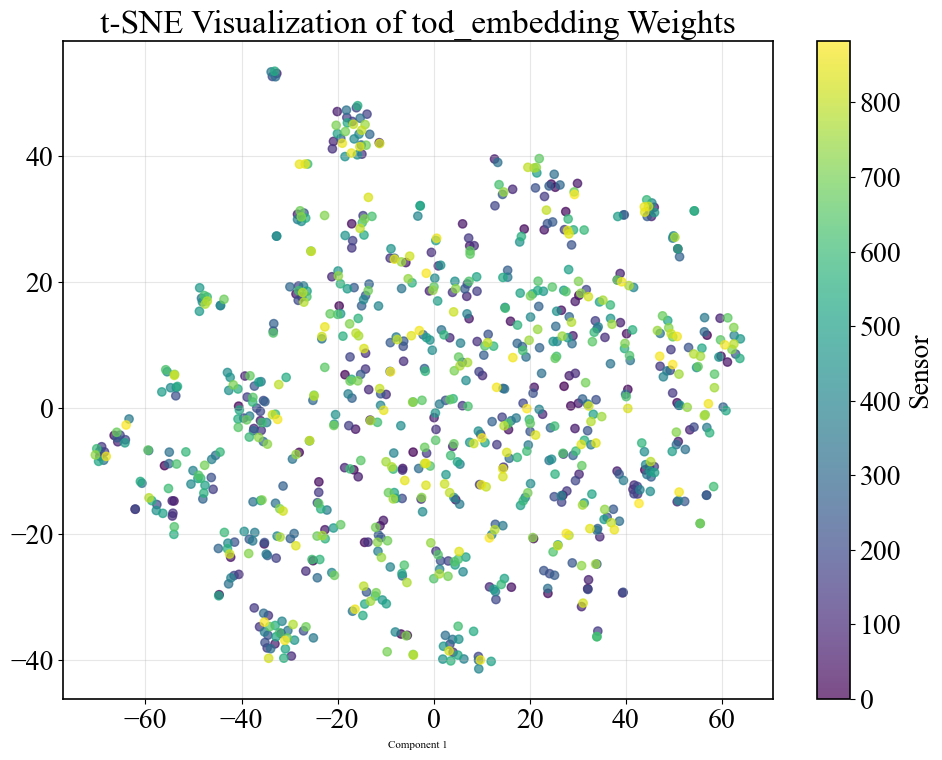

In [11]:
# 获取嵌入权重 (steps_per_day, tod_embedding_dim)
embedding_weights = model.adaptive_embedding.detach().cpu().numpy()[0]

# 使用 t-SNE 或 PCA 进行降维
reducer = TSNE(n_components=2, random_state=42, perplexity=10)
# title = 't-SNE Visualization of adaptive_embedding Weights'

# 执行降维
embedded = reducer.fit_transform(embedding_weights)

# 绘制结果
plt.figure(figsize=(10, 8))
plt.scatter(embedded[:, 0], embedded[:, 1], c=np.arange(len(embedded)), cmap='viridis', alpha=0.7)


plt.colorbar(label='Sensor')
plt.title(title)
plt.xlabel('Component 1', fontsize=8)
# plt.ylabel('Component 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

plt.figure(figsize=(10, 8))
plt.scatter(embedded[:, 0], embedded[:, 1], c=np.arange(len(embedded)), cmap='viridis', alpha=0.7)

# 收集所有要标注的文本对象
texts = []
target_labels = [10, 143, 60, 68, 118, 140, 79, 114, 18, ]   # 可以添加更多需要标注的点
for i in target_labels:
    texts.append(plt.annotate(
        str(i), 
        (embedded[i, 0], embedded[i, 1]),
        fontsize=12,
        alpha=0.9
    ))

# 自动调整标签位置，避免重叠
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.3),  # 可选：添加箭头指向原位置
    force_points=0.7  # 调整标签的分散程度
)

plt.colorbar(label='Sensor')
# plt.xlabel('Component 1', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../fig/位置嵌入可视化.jpg")
plt.show()